# 📓 Notebook 06 — Behavioral Scoring Model (BSM)
## Module de Scoring Comportemental des Sessions sans OTP
### Algorithme : XGBoost (Gradient Boosting)
---
**Objectif** : Entraîner un modèle capable d'évaluer le risque d'une session de paiement
en ligne lorsque la validation OTP est absente.

**Sortie** : Décision tri-classe → `Approuver` / `Challenger` / `Bloquer`

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score, precision_score
)
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
import shap

np.random.seed(42)
plt.style.use('dark_background')
COLORS = {'approve':'#10b981', 'challenge':'#f59e0b', 'block':'#ef4444'}

print('✅ Imports OK')
print(f'   NumPy    : {np.__version__}')
print(f'   Pandas   : {pd.__version__}')

✅ Imports OK
   NumPy    : 1.26.4
   Pandas   : 2.2.2


## 2. Génération du Dataset Synthétique de Sessions

### Pourquoi des données synthétiques ?
Les données réelles de sessions (comportement souris, vitesse de frappe) sont des données
personnelles sensibles inaccessibles dans un contexte de stage. On génère donc un dataset
synthétique réaliste basé sur la littérature académique en cybersécurité.

**3 profils de sessions** :
- `0` — Session **légitime** : comportement humain naturel, appareil connu, contexte normal
- `1` — Session **suspecte** (Challenger) : quelques anomalies, nécessite vérification
- `2` — Session **frauduleuse** (Bloquer) : bot/attaquant, VPN, nouveau bénéficiaire, montant anormal

In [2]:
def generate_session_dataset(n_sessions=50000, fraud_rate=0.03, suspect_rate=0.08):
    """
    Génère un dataset synthétique de sessions de paiement.
    
    Labels:
        0 = Légitime  (Approuver)
        1 = Suspect   (Challenger)
        2 = Frauduleux (Bloquer)
    """
    rng = np.random.RandomState(42)
    n_fraud   = int(n_sessions * fraud_rate)
    n_suspect = int(n_sessions * suspect_rate)
    n_legit   = n_sessions - n_fraud - n_suspect

    records = []

    # ── Profil 0 : Sessions légitimes ──────────────────────────
    for _ in range(n_legit):
        records.append({
            # Features comportementales
            'typing_speed_ms':        rng.normal(180, 40),      # frappe naturelle
            'typing_regularity':      rng.uniform(0.6, 1.0),    # régularité (0=bot, 1=humain)
            'copy_paste_detected':    rng.choice([0, 1], p=[0.85, 0.15]),
            'mouse_movement_entropy': rng.uniform(0.6, 1.0),    # mouvements naturels
            'time_on_page_sec':       rng.normal(45, 15),
            'field_focus_changes':    rng.randint(3, 12),
            'form_fill_duration_ms':  rng.normal(12000, 3000),
            'tab_switches':           rng.randint(0, 4),
            'scroll_events':          rng.randint(2, 20),
            # Features contexte
            'is_new_device':          rng.choice([0, 1], p=[0.95, 0.05]),
            'device_fingerprint_match': rng.choice([0, 1], p=[0.05, 0.95]),
            'ip_country_match':       rng.choice([0, 1], p=[0.02, 0.98]),
            'ip_is_vpn_proxy':        rng.choice([0, 1], p=[0.97, 0.03]),
            'time_since_last_login_min': rng.exponential(120),
            'login_failed_attempts':  rng.choice([0, 1, 2], p=[0.90, 0.08, 0.02]),
            'session_age_sec':        rng.normal(300, 120),
            'is_mobile_desktop_mismatch': rng.choice([0, 1], p=[0.97, 0.03]),
            # Features transaction
            'is_new_beneficiary':     rng.choice([0, 1], p=[0.80, 0.20]),
            'amt_vs_avg_ratio':       rng.normal(1.0, 0.3),
            'transactions_last_hour': rng.randint(0, 3),
            'is_international':       rng.choice([0, 1], p=[0.90, 0.10]),
            'hour_of_day':            rng.randint(8, 22),
            'is_weekend':             rng.choice([0, 1], p=[0.70, 0.30]),
            'label': 0
        })

    # ── Profil 1 : Sessions suspectes ──────────────────────────
    for _ in range(n_suspect):
        records.append({
            'typing_speed_ms':        rng.normal(130, 60),
            'typing_regularity':      rng.uniform(0.3, 0.7),
            'copy_paste_detected':    rng.choice([0, 1], p=[0.50, 0.50]),
            'mouse_movement_entropy': rng.uniform(0.3, 0.7),
            'time_on_page_sec':       rng.normal(20, 10),
            'field_focus_changes':    rng.randint(1, 6),
            'form_fill_duration_ms':  rng.normal(5000, 2000),
            'tab_switches':           rng.randint(0, 2),
            'scroll_events':          rng.randint(0, 5),
            'is_new_device':          rng.choice([0, 1], p=[0.70, 0.30]),
            'device_fingerprint_match': rng.choice([0, 1], p=[0.30, 0.70]),
            'ip_country_match':       rng.choice([0, 1], p=[0.20, 0.80]),
            'ip_is_vpn_proxy':        rng.choice([0, 1], p=[0.70, 0.30]),
            'time_since_last_login_min': rng.exponential(20),
            'login_failed_attempts':  rng.choice([0, 1, 2, 3], p=[0.40, 0.35, 0.15, 0.10]),
            'session_age_sec':        rng.normal(80, 40),
            'is_mobile_desktop_mismatch': rng.choice([0, 1], p=[0.70, 0.30]),
            'is_new_beneficiary':     rng.choice([0, 1], p=[0.40, 0.60]),
            'amt_vs_avg_ratio':       rng.normal(2.0, 0.8),
            'transactions_last_hour': rng.randint(2, 6),
            'is_international':       rng.choice([0, 1], p=[0.60, 0.40]),
            'hour_of_day':            rng.randint(0, 24),
            'is_weekend':             rng.choice([0, 1], p=[0.50, 0.50]),
            'label': 1
        })

    # ── Profil 2 : Sessions frauduleuses ───────────────────────
    for _ in range(n_fraud):
        records.append({
            'typing_speed_ms':        rng.normal(30, 10),       # trop rapide = bot
            'typing_regularity':      rng.uniform(0.0, 0.2),    # trop régulier = bot
            'copy_paste_detected':    rng.choice([0, 1], p=[0.10, 0.90]),
            'mouse_movement_entropy': rng.uniform(0.0, 0.2),    # souris rectiligne
            'time_on_page_sec':       rng.normal(5, 3),
            'field_focus_changes':    rng.randint(0, 2),
            'form_fill_duration_ms':  rng.normal(800, 300),
            'tab_switches':           0,
            'scroll_events':          0,
            'is_new_device':          rng.choice([0, 1], p=[0.20, 0.80]),
            'device_fingerprint_match': rng.choice([0, 1], p=[0.85, 0.15]),
            'ip_country_match':       rng.choice([0, 1], p=[0.80, 0.20]),
            'ip_is_vpn_proxy':        rng.choice([0, 1], p=[0.20, 0.80]),
            'time_since_last_login_min': rng.exponential(3),
            'login_failed_attempts':  rng.choice([0, 1, 2, 3, 4], p=[0.10, 0.15, 0.25, 0.30, 0.20]),
            'session_age_sec':        rng.normal(15, 8),
            'is_mobile_desktop_mismatch': rng.choice([0, 1], p=[0.30, 0.70]),
            'is_new_beneficiary':     rng.choice([0, 1], p=[0.05, 0.95]),
            'amt_vs_avg_ratio':       rng.normal(5.0, 2.0),
            'transactions_last_hour': rng.randint(5, 20),
            'is_international':       rng.choice([0, 1], p=[0.20, 0.80]),
            'hour_of_day':            rng.choice(list(range(0, 6)) + list(range(22, 24))),
            'is_weekend':             rng.choice([0, 1], p=[0.40, 0.60]),
            'label': 2
        })

    df = pd.DataFrame(records)
    # Nettoyer les valeurs aberrantes
    df['typing_speed_ms']       = df['typing_speed_ms'].clip(0, 500)
    df['time_on_page_sec']      = df['time_on_page_sec'].clip(0, 300)
    df['form_fill_duration_ms'] = df['form_fill_duration_ms'].clip(0, 60000)
    df['session_age_sec']       = df['session_age_sec'].clip(0, 3600)
    df['amt_vs_avg_ratio']      = df['amt_vs_avg_ratio'].clip(0, 20)
    return df.sample(frac=1, random_state=42).reset_index(drop=True)


df = generate_session_dataset(n_sessions=50000)
print(f'✅ Dataset généré : {df.shape}')
print(f'\nDistribution des labels :')
label_map = {0: 'Légitime (Approuver)', 1: 'Suspect (Challenger)', 2: 'Frauduleux (Bloquer)'}
for k, v in label_map.items():
    n = (df['label'] == k).sum()
    print(f'   {v} : {n:,} ({n/len(df)*100:.1f}%)')
df.head()

✅ Dataset généré : (50000, 24)

Distribution des labels :
   Légitime (Approuver) : 44,500 (89.0%)
   Suspect (Challenger) : 4,000 (8.0%)
   Frauduleux (Bloquer) : 1,500 (3.0%)


,typing_speed_ms,typing_regularity,copy_paste_detected,mouse_movement_entropy,time_on_page_sec,field_focus_changes,form_fill_duration_ms,tab_switches,scroll_events,is_new_device,...,login_failed_attempts,session_age_sec,is_mobile_desktop_mismatch,is_new_beneficiary,amt_vs_avg_ratio,transactions_last_hour,is_international,hour_of_day,is_weekend,label
0,161.919782,0.614213,0,0.605333,73.977665,4,13053.024049,0,8,0,...,0,263.489463,0,0,0.900200,2,0,9,0,0
1,121.870491,0.942662,1,0.942242,67.312907,3,14559.658572,2,13,0,...,0,301.468207,0,0,0.907296,2,0,14,0,0
2,167.368705,0.655052,0,0.961289,17.801501,10,8824.168228,0,8,0,...,1,420.525196,0,0,0.789839,1,0,14,0,0
3,216.722067,0.690690,0,0.667173,19.278261,6,15655.544276,0,17,0,...,0,322.386630,0,0,1.202543,0,0,17,1,0
4,219.736086,0.610227,0,0.643640,38.809618,11,6961.485996,3,8,0,...,0,419.925817,0,1,1.121856,0,0,18,1,0


## 3. Analyse Exploratoire du Dataset BSM

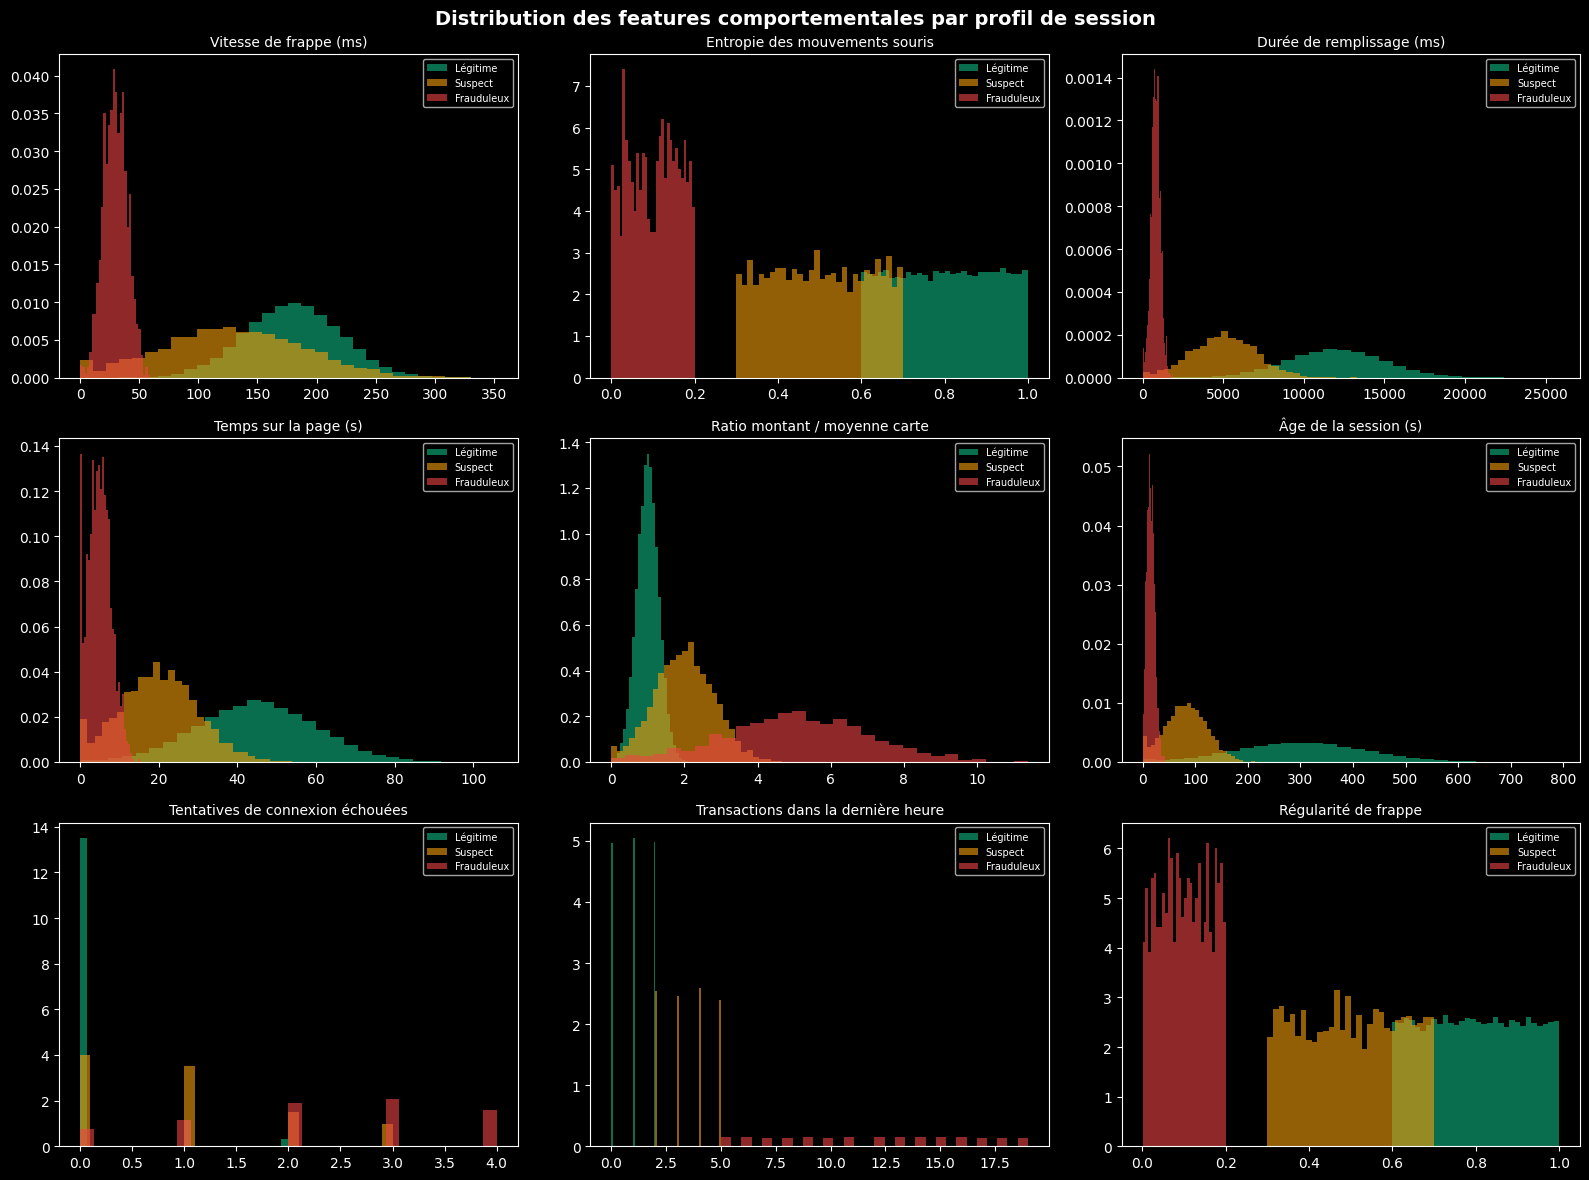

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Distribution des features comportementales par profil de session', fontsize=14, fontweight='bold')

features_to_plot = [
    ('typing_speed_ms',       'Vitesse de frappe (ms)'),
    ('mouse_movement_entropy','Entropie des mouvements souris'),
    ('form_fill_duration_ms', 'Durée de remplissage (ms)'),
    ('time_on_page_sec',      'Temps sur la page (s)'),
    ('amt_vs_avg_ratio',      'Ratio montant / moyenne carte'),
    ('session_age_sec',       'Âge de la session (s)'),
    ('login_failed_attempts', 'Tentatives de connexion échouées'),
    ('transactions_last_hour','Transactions dans la dernière heure'),
    ('typing_regularity',     'Régularité de frappe'),
]

colors = [COLORS['approve'], COLORS['challenge'], COLORS['block']]
labels = ['Légitime', 'Suspect', 'Frauduleux']

for idx, (feat, title) in enumerate(features_to_plot):
    ax = axes[idx // 3][idx % 3]
    for label_val, color, label_name in zip([0, 1, 2], colors, labels):
        data = df[df['label'] == label_val][feat]
        ax.hist(data, bins=30, alpha=0.6, color=color, label=label_name, density=True)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('../models/bsm_feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

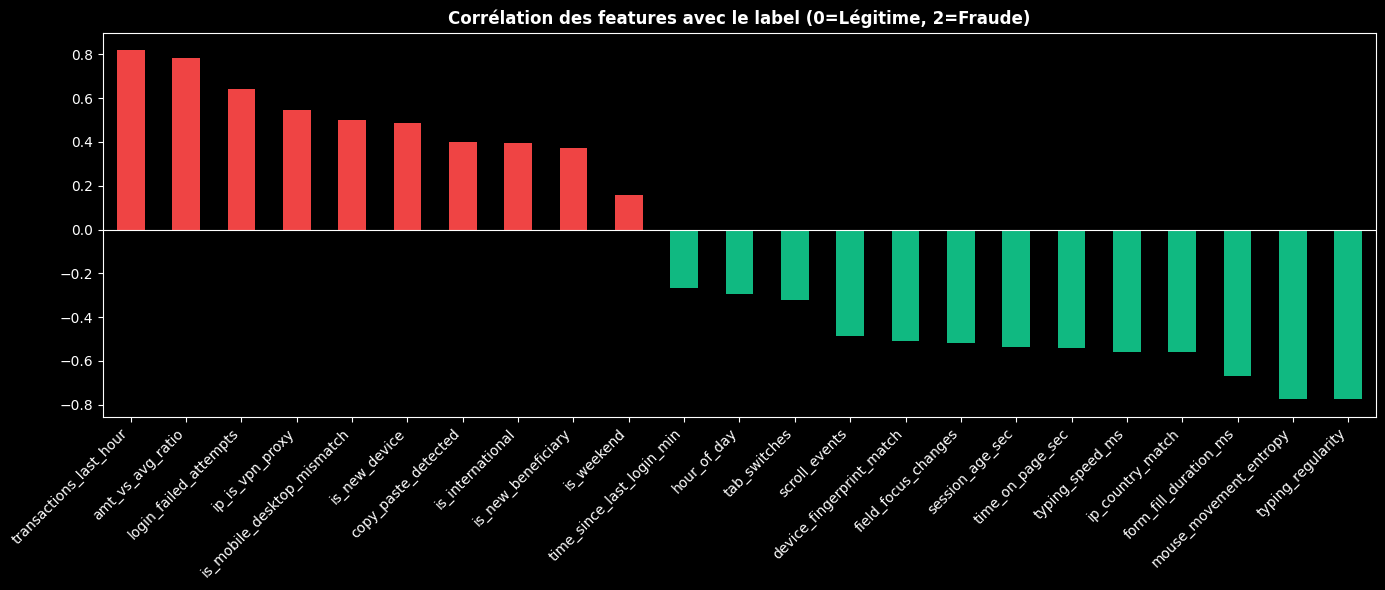


Top 5 features les plus corrélées à la fraude :
transactions_last_hour    0.818227
amt_vs_avg_ratio          0.785098
typing_regularity         0.774654
mouse_movement_entropy    0.774261
form_fill_duration_ms     0.667063
Name: label, dtype: float64


In [4]:
# Corrélation avec le label
plt.figure(figsize=(14, 6))
correlations = df.corr()['label'].drop('label').sort_values(ascending=False)
colors_bar = ['#ef4444' if v > 0 else '#10b981' for v in correlations]
correlations.plot(kind='bar', color=colors_bar, figsize=(14, 6))
plt.title('Corrélation des features avec le label (0=Légitime, 2=Fraude)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='white', linewidth=0.8)
plt.tight_layout()
plt.show()
print('\nTop 5 features les plus corrélées à la fraude :')
print(correlations.abs().nlargest(5))

## 4. Préparation des Données

In [5]:
FEATURE_COLS = [
    # Comportementales
    'typing_speed_ms', 'typing_regularity', 'copy_paste_detected',
    'mouse_movement_entropy', 'time_on_page_sec', 'field_focus_changes',
    'form_fill_duration_ms', 'tab_switches', 'scroll_events',
    # Contexte
    'is_new_device', 'device_fingerprint_match', 'ip_country_match',
    'ip_is_vpn_proxy', 'time_since_last_login_min', 'login_failed_attempts',
    'session_age_sec', 'is_mobile_desktop_mismatch',
    # Transaction
    'is_new_beneficiary', 'amt_vs_avg_ratio', 'transactions_last_hour',
    'is_international', 'hour_of_day', 'is_weekend',
]

X = df[FEATURE_COLS].values
y = df['label'].values

# Split stratifié (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Normalisation (utile pour SHAP, même si XGBoost peu sensible à l'échelle)
scaler_bsm = StandardScaler()
X_train_sc  = scaler_bsm.fit_transform(X_train)
X_test_sc   = scaler_bsm.transform(X_test)

print(f'✅ Split effectué')
print(f'   Train : {X_train_sc.shape} | Test : {X_test_sc.shape}')
print(f'   Distribution train → 0:{(y_train==0).sum():,}  1:{(y_train==1).sum():,}  2:{(y_train==2).sum():,}')

✅ Split effectué
   Train : (40000, 23) | Test : (10000, 23)
   Distribution train → 0:35,600  1:3,200  2:1,200


## 5. Entraînement du Modèle XGBoost (BSM)

In [6]:
# Calcul des poids de classe pour gérer le déséquilibre
# (fraudes rares → poids plus élevé)
class_counts = np.bincount(y_train)
total        = len(y_train)
class_weights = {i: total / (len(class_counts) * c) for i, c in enumerate(class_counts)}
sample_weights = np.array([class_weights[y] for y in y_train])

print('Poids des classes :')
for k, v in class_weights.items():
    print(f'   Classe {k} ({label_map[k]}) : {v:.2f}')

Poids des classes :
   Classe 0 (Légitime (Approuver)) : 0.37
   Classe 1 (Suspect (Challenger)) : 4.17
   Classe 2 (Frauduleux (Bloquer)) : 11.11


In [7]:
bsm = XGBClassifier(
    n_estimators      = 400,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    gamma             = 0.1,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    num_class         = 3,
    objective         = 'multi:softprob',
    eval_metric       = 'mlogloss',
    tree_method       = 'hist',
    random_state      = 42,
    n_jobs            = -1,
    early_stopping_rounds = 20,
    verbosity         = 0,
)

# Entraînement avec early stopping
bsm.fit(
    X_train_sc, y_train,
    sample_weight       = sample_weights,
    eval_set            = [(X_test_sc, y_test)],
    verbose             = 50,
)

print(f'\n✅ Entraînement terminé — meilleure itération : {bsm.best_iteration}')

[0]	validation_0-mlogloss:1.02516
[50]	validation_0-mlogloss:0.06693
[100]	validation_0-mlogloss:0.00613
[150]	validation_0-mlogloss:0.00100
[200]	validation_0-mlogloss:0.00047
[250]	validation_0-mlogloss:0.00041
[300]	validation_0-mlogloss:0.00041
[307]	validation_0-mlogloss:0.00041

✅ Entraînement terminé — meilleure itération : 287


## 6. Évaluation des Performances

In [8]:
y_pred      = bsm.predict(X_test_sc)
y_prob      = bsm.predict_proba(X_test_sc)
target_names = ['Légitime', 'Suspect', 'Frauduleux']

print('=' * 60)
print('  RAPPORT DE CLASSIFICATION — BSM (XGBoost)')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=target_names))

# AUC-ROC multiclasse (One-vs-Rest)
auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
print(f'AUC-ROC (weighted OvR) : {auc:.4f}')

  RAPPORT DE CLASSIFICATION — BSM (XGBoost)
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00      8900
     Suspect       1.00      1.00      1.00       800
  Frauduleux       1.00      1.00      1.00       300

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

AUC-ROC (weighted OvR) : 1.0000


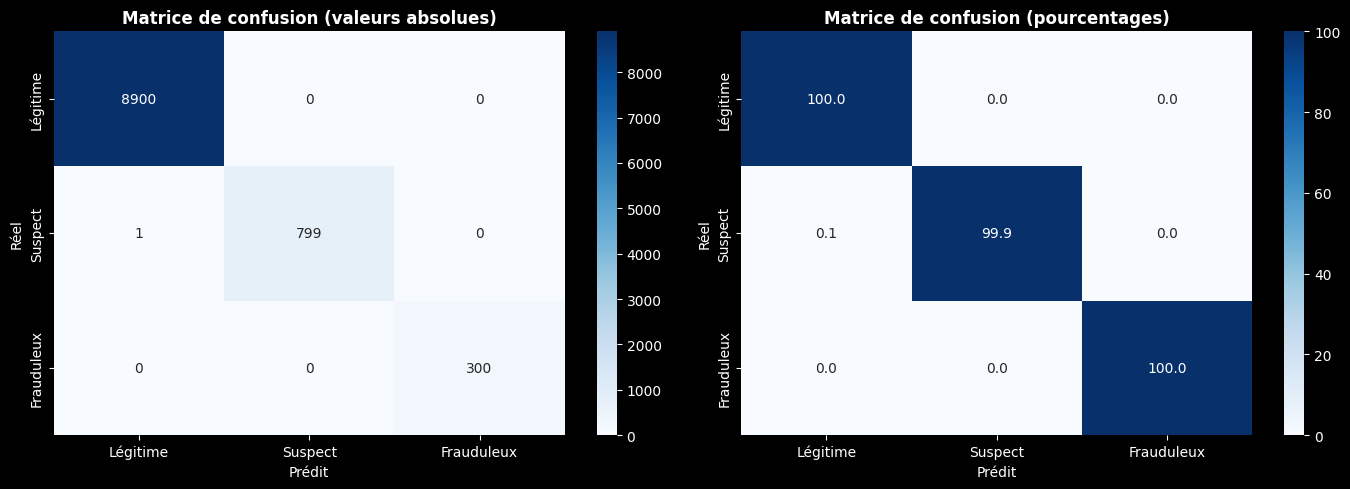


🎯 Taux de faux positifs (légitimes bloqués à tort) : 0.00%
   Critère de réussite du CDC : < 5% — ✅ ATTEINT


In [9]:
# Matrice de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[0])
axes[0].set_title('Matrice de confusion (valeurs absolues)', fontweight='bold')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_title('Matrice de confusion (pourcentages)', fontweight='bold')
axes[1].set_ylabel('Réel')
axes[1].set_xlabel('Prédit')

plt.tight_layout()
plt.savefig('../models/bsm_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# Taux de faux positifs (légitimes bloqués à tort)
fp_rate = cm[0, 2] / cm[0].sum() * 100
print(f'\n🎯 Taux de faux positifs (légitimes bloqués à tort) : {fp_rate:.2f}%')
print(f'   Critère de réussite du CDC : < 5% — {"✅ ATTEINT" if fp_rate < 5 else "❌ À améliorer"}')

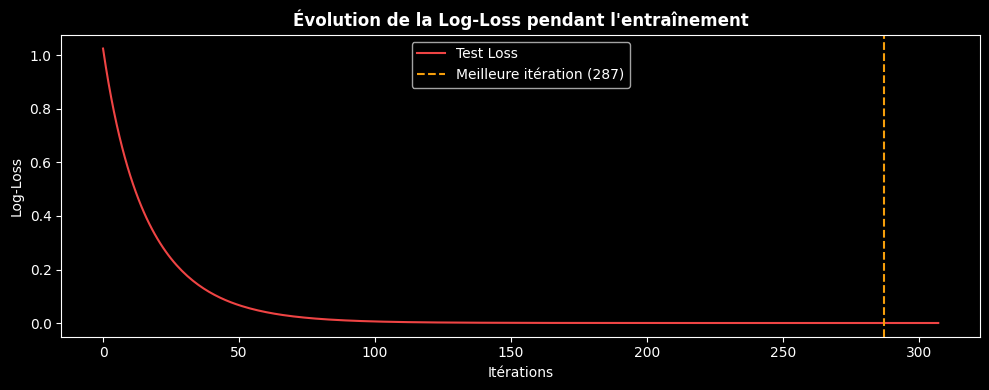

In [10]:
# Courbes d'apprentissage (loss par itération)
results = bsm.evals_result()
if results:
    plt.figure(figsize=(10, 4))
    plt.plot(results['validation_0']['mlogloss'], color='#ef4444', label='Test Loss')
    plt.axvline(x=bsm.best_iteration, color='#f59e0b', linestyle='--', label=f'Meilleure itération ({bsm.best_iteration})')
    plt.title('Évolution de la Log-Loss pendant l\'entraînement', fontweight='bold')
    plt.xlabel('Itérations')
    plt.ylabel('Log-Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig('../models/bsm_training_curve.png', dpi=120, bbox_inches='tight')
    plt.show()

## 7. Interprétabilité avec SHAP

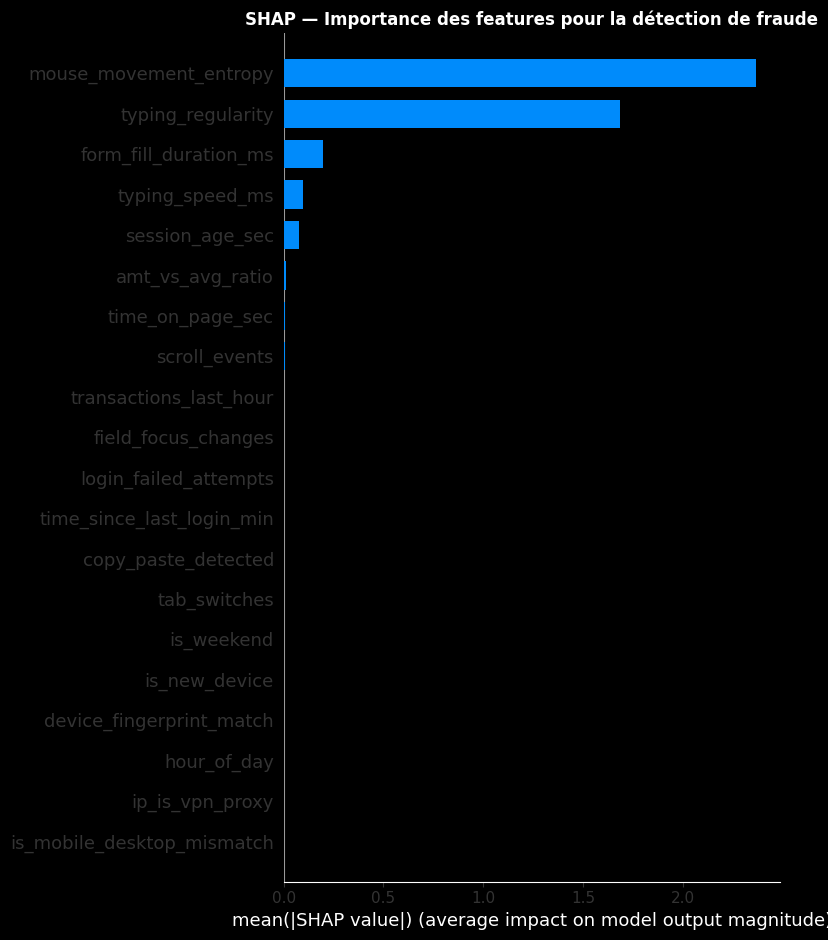

In [11]:
# Calcul des SHAP values (sur un échantillon pour la vitesse)
explainer  = shap.TreeExplainer(bsm)
sample_idx = np.random.choice(len(X_test_sc), size=min(1000, len(X_test_sc)), replace=False)
X_sample   = X_test_sc[sample_idx]
shap_values = explainer.shap_values(X_sample)

# Correction pour le format multi-classe (XGBoost)
# shap_values peut être une liste ou un array 3D (samples, features, classes)
if isinstance(shap_values, list):
    shap_vals_fraud = shap_values[2]
else:
    shap_vals_fraud = shap_values[:, :, 2]

# SHAP summary pour la classe 2 (Frauduleux)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals_fraud, X_sample,
    feature_names=FEATURE_COLS,
    show=False, plot_type='bar'
)
plt.title('SHAP — Importance des features pour la détection de fraude', fontweight='bold')
plt.tight_layout()
plt.savefig('../models/bsm_shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()

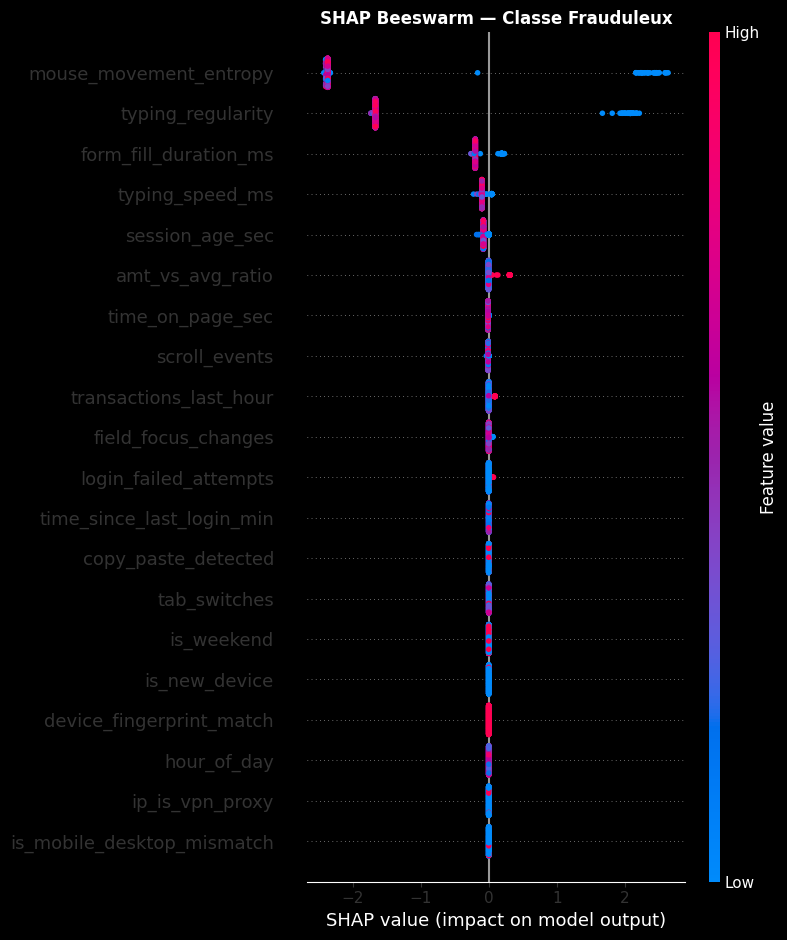

In [12]:
# SHAP beeswarm — impact détaillé de chaque feature
plt.figure(figsize=(10, 9))
shap.summary_plot(
    shap_vals_fraud, X_sample,
    feature_names=FEATURE_COLS,
    show=False
)
plt.title('SHAP Beeswarm — Classe Frauduleux', fontweight='bold')
plt.tight_layout()
plt.savefig('../models/bsm_shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Validation Croisée

In [13]:
# Cross-validation 5 folds sur le F1 macro
bsm_cv = XGBClassifier(
    n_estimators=bsm.best_iteration,
    max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=3,
    eval_metric='mlogloss', tree_method='hist',
    random_state=42, n_jobs=-1, verbosity=0,
)

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1  = cross_val_score(bsm_cv, X_train_sc, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)

print('Validation croisée (5-Fold) — F1 Macro :')
print(f'   Scores  : {[f"{s:.4f}" for s in cv_f1]}')
print(f'   Moyenne : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

Validation croisée (5-Fold) — F1 Macro :
   Scores  : ['1.0000', '1.0000', '0.9997', '1.0000', '0.9997']
   Moyenne : 0.9999 ± 0.0001


## 9. Définition des Seuils de Décision

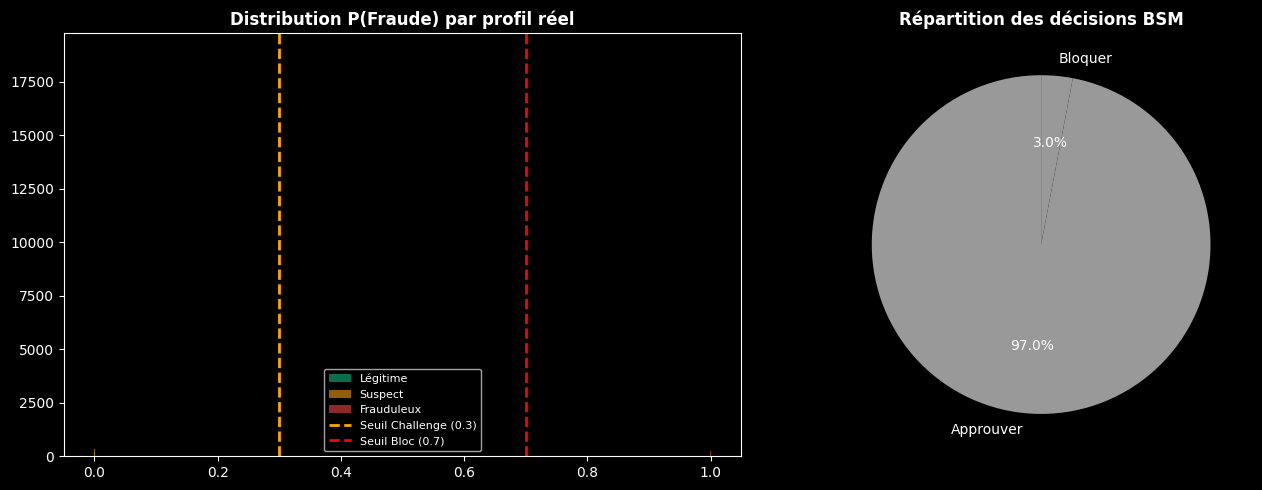


Seuils de décision :
   P(fraude) < 0.3  → ✅ Approuver
   P(fraude) ∈ [0.3, 0.7[ → ⚠️  Challenger
   P(fraude) ≥ 0.7  → 🚨 Bloquer


In [14]:
# Le BSM retourne 3 probabilités : P(légitime), P(suspect), P(frauduleux)
# On définit des seuils sur P(frauduleux) pour la décision finale
THRESHOLD_CHALLENGE = 0.30   # P(fraude) >= 0.30 → Challenger
THRESHOLD_BLOCK     = 0.70   # P(fraude) >= 0.70 → Bloquer

def bsm_decision(proba_fraud):
    """Retourne la décision finale selon la probabilité de fraude."""
    if proba_fraud >= THRESHOLD_BLOCK:
        return 'Bloquer',     2, '#ef4444'
    elif proba_fraud >= THRESHOLD_CHALLENGE:
        return 'Challenger',  1, '#f59e0b'
    else:
        return 'Approuver',   0, '#10b981'

# Analyse de la distribution des probabilités de fraude sur le test set
proba_fraud_test = y_prob[:, 2]  # probabilité classe 2 = fraude

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des probabilités
axes[0].hist(proba_fraud_test[y_test == 0], bins=50, alpha=0.6, color=COLORS['approve'], label='Légitime', density=True)
axes[0].hist(proba_fraud_test[y_test == 1], bins=50, alpha=0.6, color=COLORS['challenge'], label='Suspect', density=True)
axes[0].hist(proba_fraud_test[y_test == 2], bins=50, alpha=0.6, color=COLORS['block'], label='Frauduleux', density=True)
axes[0].axvline(THRESHOLD_CHALLENGE, color='orange', linestyle='--', linewidth=2, label=f'Seuil Challenge ({THRESHOLD_CHALLENGE})')
axes[0].axvline(THRESHOLD_BLOCK,     color='red',    linestyle='--', linewidth=2, label=f'Seuil Bloc ({THRESHOLD_BLOCK})')
axes[0].set_title('Distribution P(Fraude) par profil réel', fontweight='bold')
axes[0].legend(fontsize=8)

# Répartition des décisions
decisions  = [bsm_decision(p)[0] for p in proba_fraud_test]
dec_counts = pd.Series(decisions).value_counts()
colors_pie = [COLORS['approve'], COLORS['challenge'], COLORS['block']]
axes[1].pie(dec_counts.values, labels=dec_counts.index, colors=[COLORS.get(d.lower(), '#999') for d in dec_counts.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Répartition des décisions BSM', fontweight='bold')

plt.tight_layout()
plt.savefig('../models/bsm_decision_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nSeuils de décision :')
print(f'   P(fraude) < {THRESHOLD_CHALLENGE}  → ✅ Approuver')
print(f'   P(fraude) ∈ [{THRESHOLD_CHALLENGE}, {THRESHOLD_BLOCK}[ → ⚠️  Challenger')
print(f'   P(fraude) ≥ {THRESHOLD_BLOCK}  → 🚨 Bloquer')

## 10. Sauvegarde des Artefacts

In [15]:
# ── Modèle BSM ───────────────────────────────────────────────
bsm.save_model('../models/bsm_model.json')          # format natif XGBoost
with open('../models/bsm_model.pkl', 'wb') as f:    # format scikit-learn
    pickle.dump(bsm, f)

# ── Scaler BSM ───────────────────────────────────────────────
with open('../models/bsm_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_bsm, f)

# ── Feature columns ─────────────────────────────────────────
with open('../models/bsm_feature_columns.json', 'w') as f:
    json.dump(FEATURE_COLS, f, ensure_ascii=False)

# ── Configuration ────────────────────────────────────────────
bsm_config = {
    'model_version':      '1.0',
    'algorithm':          'XGBoost',
    'n_features':         len(FEATURE_COLS),
    'n_classes':          3,
    'class_labels':       {0: 'Approuver', 1: 'Challenger', 2: 'Bloquer'},
    'threshold_challenge': THRESHOLD_CHALLENGE,
    'threshold_block':     THRESHOLD_BLOCK,
    'best_iteration':      int(bsm.best_iteration),
    'feature_cols':        FEATURE_COLS,
}
with open('../models/bsm_config.json', 'w') as f:
    json.dump(bsm_config, f, ensure_ascii=False, indent=2)

print('✅ Artefacts BSM sauvegardés :')
print('   models/bsm_model.json')
print('   models/bsm_model.pkl')
print('   models/bsm_scaler.pkl')
print('   models/bsm_feature_columns.json')
print('   models/bsm_config.json')
print(f'\n📊 Résumé des performances :')
print(f'   F1 Macro        : {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'   AUC-ROC (OvR)   : {auc:.4f}')
print(f'   Faux positifs   : {fp_rate:.2f}%')
print(f'   Critère CDC     : {"✅ ATTEINT" if fp_rate < 5 else "❌ À améliorer"}')

✅ Artefacts BSM sauvegardés :
   models/bsm_model.json
   models/bsm_model.pkl
   models/bsm_scaler.pkl
   models/bsm_feature_columns.json
   models/bsm_config.json

📊 Résumé des performances :
   F1 Macro        : 0.9998
   AUC-ROC (OvR)   : 1.0000
   Faux positifs   : 0.00%
   Critère CDC     : ✅ ATTEINT


---
## Résumé du Module BSM

| Paramètre | Valeur |
|---|---|
| Algorithme | XGBoost (Gradient Boosting) |
| Type de problème | Classification multi-classes (3 classes) |
| Features | 23 features comportementales et contextuelles |
| Sortie | P(Légitime) / P(Suspect) / P(Fraude) |
| Décision | Approuver / Challenger / Bloquer |
| Interprétabilité | SHAP values |

**Artefacts générés** :
- `bsm_model.json` + `bsm_model.pkl` — modèle entraîné
- `bsm_scaler.pkl` — normalisateur des features
- `bsm_config.json` — configuration et seuils
- `bsm_feature_columns.json` — liste ordonnée des features